The following additional libraries are needed to run this
notebook. Note that running on Colab is experimental, please report a Github
issue if you have any problem.

# Task 1: tune the hyperparameters in that model to improve the accuracy


In [5]:
import math
import pandas as pd
import torch
from torch import nn
import d2l

In [6]:
class PositionWiseFFN(nn.Module):  #@save
    """The positionwise feed-forward network."""
    def __init__(self, ffn_num_hiddens, ffn_num_outputs):
        super().__init__()
        self.dense1 = nn.LazyLinear(ffn_num_hiddens)
        self.relu = nn.ReLU()
        self.dense2 = nn.LazyLinear(ffn_num_outputs)

    def forward(self, X):
        return self.dense2(self.relu(self.dense1(X)))

The following example
shows that [**the innermost dimension
of a tensor changes**] to
the number of outputs in
the positionwise feed-forward network.
Since the same MLP transforms
at all the positions,
when the inputs at all these positions are the same,
their outputs are also identical.


In [7]:
ffn = PositionWiseFFN(4, 8)
ffn.eval()
ffn(torch.ones((2, 3, 4)))[0]

tensor([[-0.0504, -0.4935,  0.3047, -0.3551,  0.3511,  0.5854, -0.0996,  0.4240],
        [-0.0504, -0.4935,  0.3047, -0.3551,  0.3511,  0.5854, -0.0996,  0.4240],
        [-0.0504, -0.4935,  0.3047, -0.3551,  0.3511,  0.5854, -0.0996,  0.4240]],
       grad_fn=<SelectBackward0>)

## Residual Connection and Layer Normalization


The following code snippet
[**compares the normalization across different dimensions
by layer normalization and batch normalization**].


In [8]:
ln = nn.LayerNorm(2)
bn = nn.LazyBatchNorm1d()
X = torch.tensor([[1, 2], [2, 3]], dtype=torch.float32)
# Compute mean and variance from X in the training mode
print('layer norm:', ln(X), '\nbatch norm:', bn(X))

layer norm: tensor([[-1.0000,  1.0000],
        [-1.0000,  1.0000]], grad_fn=<NativeLayerNormBackward0>) 
batch norm: tensor([[-1.0000, -1.0000],
        [ 1.0000,  1.0000]], grad_fn=<NativeBatchNormBackward0>)


Now we can implement the `AddNorm` class
[**using a residual connection followed by layer normalization**].
Dropout is also applied for regularization.


In [9]:
class AddNorm(nn.Module):  #@save
    """The residual connection followed by layer normalization."""
    def __init__(self, norm_shape, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(norm_shape)

    def forward(self, X, Y):
        return self.ln(self.dropout(Y) + X)

The residual connection requires that
the two inputs are of the same shape
so that [**the output tensor also has the same shape after the addition operation**].


In [10]:
add_norm = AddNorm(4, 0.5)
shape = (2, 3, 4)
d2l.check_shape(add_norm(torch.ones(shape), torch.ones(shape)), shape)

## Encoder

The following `TransformerEncoderBlock` class
contains two sublayers: multi-head self-attention and positionwise feed-forward networks,
where a residual connection followed by layer normalization is employed
around both sublayers.


In [11]:
class TransformerEncoderBlock(nn.Module):  #@save
    """The Transformer encoder block."""
    def __init__(self, num_hiddens, ffn_num_hiddens, num_heads, dropout,
                 use_bias=False):
        super().__init__()
        self.attention = d2l.MultiHeadAttention(num_hiddens, num_heads,
                                                dropout, use_bias)
        self.addnorm1 = AddNorm(num_hiddens, dropout)
        self.ffn = PositionWiseFFN(ffn_num_hiddens, num_hiddens)
        self.addnorm2 = AddNorm(num_hiddens, dropout)

    def forward(self, X, valid_lens):
        Y = self.addnorm1(X, self.attention(X, X, X, valid_lens))
        return self.addnorm2(Y, self.ffn(Y))

As we can see,
[**no layer in the Transformer encoder
changes the shape of its input.**]


In [12]:
X = torch.ones((2, 100, 24))
valid_lens = torch.tensor([3, 2])
encoder_blk = TransformerEncoderBlock(24, 48, 8, 0.5)
encoder_blk.eval()
d2l.check_shape(encoder_blk(X, valid_lens), X.shape)

In the following [**Transformer encoder**] implementation,
we stack `num_blks` instances of the above `TransformerEncoderBlock` classes.
Since we use the fixed positional encoding
whose values are always between $-1$ and $1$,
we multiply values of the learnable input embeddings
by the square root of the embedding dimension
to rescale before summing up the input embedding and the positional encoding.


In [13]:
class TransformerEncoder(d2l.Encoder):  #@save
    """The Transformer encoder."""
    def __init__(self, vocab_size, num_hiddens, ffn_num_hiddens,
                 num_heads, num_blks, dropout, use_bias=False):
        super().__init__()
        self.num_hiddens = num_hiddens
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = d2l.PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_blks):
            self.blks.add_module("block"+str(i), TransformerEncoderBlock(
                num_hiddens, ffn_num_hiddens, num_heads, dropout, use_bias))

    def forward(self, X, valid_lens):
        # Since positional encoding values are between -1 and 1, the embedding
        # values are multiplied by the square root of the embedding dimension
        # to rescale before they are summed up
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))
        self.attention_weights = [None] * len(self.blks)
        for i, blk in enumerate(self.blks):
            X = blk(X, valid_lens)
            self.attention_weights[
                i] = blk.attention.attention.attention_weights
        return X

Below we specify hyperparameters to [**create a two-layer Transformer encoder**].
The shape of the Transformer encoder output
is (batch size, number of time steps, `num_hiddens`).


In [14]:
encoder = TransformerEncoder(200, 24, 48, 8, 2, 0.5)
d2l.check_shape(encoder(torch.ones((2, 100), dtype=torch.long), valid_lens),
                (2, 100, 24))

## Decoder

As shown in :numref:`fig_transformer`,
[**the Transformer decoder
is composed of multiple identical layers**].
Each layer is implemented in the following
`TransformerDecoderBlock` class,
which contains three sublayers:
decoder self-attention,
encoder--decoder attention,
and positionwise feed-forward networks.
These sublayers employ
a residual connection around them
followed by layer normalization.


As we described earlier in this section,
in the masked multi-head decoder self-attention
(the first sublayer),
queries, keys, and values
all come from the outputs of the previous decoder layer.
When training sequence-to-sequence models,
tokens at all the positions (time steps)
of the output sequence
are known.
However,
during prediction
the output sequence is generated token by token;
thus,
at any decoder time step
only the generated tokens
can be used in the decoder self-attention.
To preserve autoregression in the decoder,
its masked self-attention
specifies  `dec_valid_lens` so that
any query
only attends to
all positions in the decoder
up to the query position.


In [15]:
class TransformerDecoderBlock(nn.Module):
    # The i-th block in the Transformer decoder
    def __init__(self, num_hiddens, ffn_num_hiddens, num_heads, dropout, i):
        super().__init__()
        self.i = i
        self.attention1 = d2l.MultiHeadAttention(num_hiddens, num_heads,
                                                 dropout)
        self.addnorm1 = AddNorm(num_hiddens, dropout)
        self.attention2 = d2l.MultiHeadAttention(num_hiddens, num_heads,
                                                 dropout)
        self.addnorm2 = AddNorm(num_hiddens, dropout)
        self.ffn = PositionWiseFFN(ffn_num_hiddens, num_hiddens)
        self.addnorm3 = AddNorm(num_hiddens, dropout)

    def forward(self, X, state):
        enc_outputs, enc_valid_lens = state[0], state[1]
        # During training, all the tokens of any output sequence are processed
        # at the same time, so state[2][self.i] is None as initialized. When
        # decoding any output sequence token by token during prediction,
        # state[2][self.i] contains representations of the decoded output at
        # the i-th block up to the current time step
        if state[2][self.i] is None:
            key_values = X
        else:
            key_values = torch.cat((state[2][self.i], X), dim=1)
        state[2][self.i] = key_values
        if self.training:
            batch_size, num_steps, _ = X.shape
            # Shape of dec_valid_lens: (batch_size, num_steps), where every
            # row is [1, 2, ..., num_steps]
            dec_valid_lens = torch.arange(
                1, num_steps + 1, device=X.device).repeat(batch_size, 1)
        else:
            dec_valid_lens = None
        # Self-attention
        X2 = self.attention1(X, key_values, key_values, dec_valid_lens)
        Y = self.addnorm1(X, X2)
        # Encoder-decoder attention. Shape of enc_outputs:
        # (batch_size, num_steps, num_hiddens)
        Y2 = self.attention2(Y, enc_outputs, enc_outputs, enc_valid_lens)
        Z = self.addnorm2(Y, Y2)
        return self.addnorm3(Z, self.ffn(Z)), state

To facilitate scaled dot product operations
in the encoder--decoder attention
and addition operations in the residual connections,
[**the feature dimension (`num_hiddens`) of the decoder is
the same as that of the encoder.**]


In [16]:
decoder_blk = TransformerDecoderBlock(24, 48, 8, 0.5, 0)
X = torch.ones((2, 100, 24))
state = [encoder_blk(X, valid_lens), valid_lens, [None]]
d2l.check_shape(decoder_blk(X, state)[0], X.shape)

Now we [**construct the entire Transformer decoder**]
composed of `num_blks` instances of `TransformerDecoderBlock`.
In the end,
a fully connected layer computes the prediction
for all the `vocab_size` possible output tokens.
Both of the decoder self-attention weights
and the encoder--decoder attention weights
are stored for later visualization.


In [17]:
class TransformerDecoder(d2l.AttentionDecoder):
    def __init__(self, vocab_size, num_hiddens, ffn_num_hiddens, num_heads,
                 num_blks, dropout):
        super().__init__()
        self.num_hiddens = num_hiddens
        self.num_blks = num_blks
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = d2l.PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_blks):
            self.blks.add_module("block"+str(i), TransformerDecoderBlock(
                num_hiddens, ffn_num_hiddens, num_heads, dropout, i))
        self.dense = nn.LazyLinear(vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens):
        return [enc_outputs, enc_valid_lens, [None] * self.num_blks]

    def forward(self, X, state):
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))
        self._attention_weights = [[None] * len(self.blks) for _ in range (2)]
        for i, blk in enumerate(self.blks):
            X, state = blk(X, state)
            # Decoder self-attention weights
            self._attention_weights[0][
                i] = blk.attention1.attention.attention_weights
            # Encoder-decoder attention weights
            self._attention_weights[1][
                i] = blk.attention2.attention.attention_weights
        return self.dense(X), state

    @property
    def attention_weights(self):
        return self._attention_weights

## [**Training**]

Let's instantiate an encoder--decoder model
by following the Transformer architecture.
Here we specify that
both the Transformer encoder and the Transformer decoder
have two layers using 4-head attention.
As in :numref:`sec_seq2seq_training`,
we train the Transformer model
for sequence-to-sequence learning on the English--French machine translation dataset.


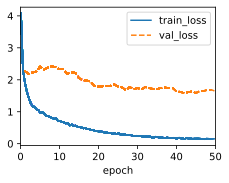

In [18]:
# larger batch size
data = d2l.MTFraEng(batch_size=128)

# Deeper network, wider feed-forward layers, and more attention heads
num_hiddens, num_blks, dropout = 256, 3, 0.2   # Increased blocks to 3
ffn_num_hiddens, num_heads = 256, 8            # Increased FFN size and heads

encoder = TransformerEncoder(
    len(data.src_vocab), num_hiddens, ffn_num_hiddens, num_heads,
    num_blks, dropout)
decoder = TransformerDecoder(
    len(data.tgt_vocab), num_hiddens, ffn_num_hiddens, num_heads,
    num_blks, dropout)

# lower learning rate for stability with a deeper model
model = d2l.Seq2Seq(encoder, decoder, tgt_pad=data.tgt_vocab['<pad>'],
                    lr=0.0005)

# Train for more epochs
trainer = d2l.Trainer(max_epochs=50, gradient_clip_val=1, num_gpus=1)
trainer.fit(model, data)

After training,
we use the Transformer model
to [**translate a few English sentences**] into French and compute their BLEU scores.


In [19]:
engs = ['go .', 'i lost .', 'he\'s calm .', 'i\'m home .']
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']
preds, _ = model.predict_step(
    data.build(engs, fras), d2l.try_gpu(), data.num_steps)
for en, fr, p in zip(engs, fras, preds):
    translation = []
    for token in data.tgt_vocab.to_tokens(p):
        if token == '<eos>':
            break
        translation.append(token)
    print(f'{en} => {translation}, bleu,'
          f'{d2l.bleu(" ".join(translation), fr, k=2):.3f}')

go . => ['va', '!'], bleu,1.000
i lost . => ["j'ai", 'perdu', '.'], bleu,1.000
he's calm . => ['il', 'est', 'mouillé', '.'], bleu,0.658
i'm home . => ['je', 'suis', 'chez', 'moi', '.'], bleu,1.000


Let's [**visualize the Transformer attention weights**] when translating the final English sentence into French.
The shape of the encoder self-attention weights
is (number of encoder layers, number of attention heads, `num_steps` or number of queries, `num_steps` or number of key-value pairs).


In [20]:
_, dec_attention_weights = model.predict_step(
    data.build([engs[-1]], [fras[-1]]), d2l.try_gpu(), data.num_steps, True)
enc_attention_weights = torch.cat(model.encoder.attention_weights, 0)
shape = (num_blks, num_heads, -1, data.num_steps)
enc_attention_weights = enc_attention_weights.reshape(shape)
d2l.check_shape(enc_attention_weights,
                (num_blks, num_heads, data.num_steps, data.num_steps))

In the encoder self-attention,
both queries and keys come from the same input sequence.
Since padding tokens do not carry meaning,
with specified valid length of the input sequence
no query attends to positions of padding tokens.
In the following,
two layers of multi-head attention weights
are presented row by row.
Each head independently attends
based on a separate representation subspace of queries, keys, and values.


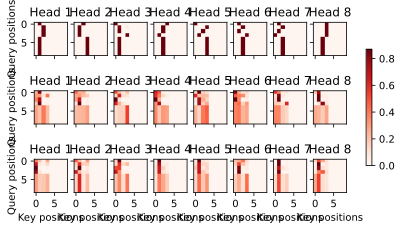

In [21]:
d2l.show_heatmaps(
    enc_attention_weights.cpu(), xlabel='Key positions',
    ylabel='Query positions', titles=['Head %d' % i for i in range(1, 9)],
    figsize=(7, 3.5))

[**To visualize the decoder self-attention weights and the encoder--decoder attention weights,
we need more data manipulations.**]
For example,
we fill the masked attention weights with zero.
Note that
the decoder self-attention weights
and the encoder--decoder attention weights
both have the same queries:
the beginning-of-sequence token followed by
the output tokens and possibly
end-of-sequence tokens.


In [22]:
dec_attention_weights_2d = [head[0].tolist()
                            for step in dec_attention_weights
                            for attn in step for blk in attn for head in blk]
dec_attention_weights_filled = torch.tensor(
    pd.DataFrame(dec_attention_weights_2d).fillna(0.0).values)
shape = (-1, 2, num_blks, num_heads, data.num_steps)
dec_attention_weights = dec_attention_weights_filled.reshape(shape)
dec_self_attention_weights, dec_inter_attention_weights = \
    dec_attention_weights.permute(1, 2, 3, 0, 4)

In [23]:
d2l.check_shape(dec_self_attention_weights,
                (num_blks, num_heads, data.num_steps, data.num_steps))
d2l.check_shape(dec_inter_attention_weights,
                (num_blks, num_heads, data.num_steps, data.num_steps))

Because of the autoregressive property of the decoder self-attention,
no query attends to key--value pairs after the query position.


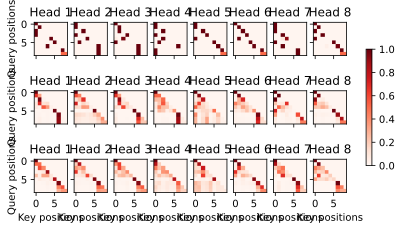

In [24]:
d2l.show_heatmaps(
    dec_self_attention_weights[:, :, :, :],
    xlabel='Key positions', ylabel='Query positions',
    titles=['Head %d' % i for i in range(1, 9)], figsize=(7, 3.5))

Similar to the case in the encoder self-attention,
via the specified valid length of the input sequence,
[**no query from the output sequence
attends to those padding tokens from the input sequence.**]


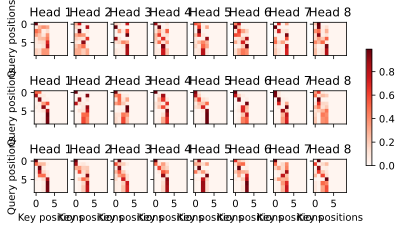

In [25]:
d2l.show_heatmaps(
    dec_inter_attention_weights, xlabel='Key positions',
    ylabel='Query positions', titles=['Head %d' % i for i in range(1, 9)],
    figsize=(7, 3.5))

## Task 2: Improve the Model (BERT Encoder)
Replace the standard Transformer encoder with a pre-trained BERT model, freezing its weights to leverage its learned representations.

--- Task 2: BERT Hybrid Results ---
go . => <unk> ., bleu 0.000
i lost . => j'ai perdu ., bleu 1.000
he's calm . => je suis <unk> ., bleu 0.000
i'm home . => je suis <unk> ., bleu 0.512


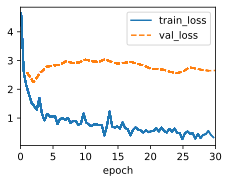

In [ ]:
# ==========================================
# TASK 2: BERT ENCODER HYBRID MODEL
# ==========================================
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from transformers import BertModel, BertTokenizer

# --- 1. Custom BERT Encoder Class ---
class BERTEncoder(d2l.Encoder):
    def __init__(self, num_hiddens, **kwargs):
        super(BERTEncoder, self).__init__(**kwargs)
        # CHANGED FOR TASK 2: Load pre-trained BERT and freeze its parameters
        # so we only train the decoder.
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        for param in self.bert.parameters():
            param.requires_grad = False

        # CHANGED FOR TASK 2: Projection layer to map BERT's 768-dim down
        # to the decoder's expected 256-dim hidden size.
        self.projection = nn.Linear(768, num_hiddens)

    def forward(self, X, valid_lens, *args):
        # CHANGED FOR TASK 2: Pass English tokens through BERT safely
        with torch.no_grad():
            outputs = self.bert(X)
        encoded_X = outputs.last_hidden_state
        return self.projection(encoded_X)

# --- 2. Custom Data Pipeline for BERT Tokens ---
# CHANGED FOR TASK 2: We intercept d2l's pipeline to tokenize the English
# source text with HuggingFace's BertTokenizer instead of the d2l vocab.
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
raw_text = d2l.read_data_nmt()
text = d2l.preprocess_nmt(raw_text)
src_sentences, tgt_sentences = d2l.tokenize_nmt(text, num_examples=data.num_train)

# Tokenize English source with BERT
src_joined = [' '.join(s) for s in src_sentences]
encoded_src = tokenizer(src_joined, padding='max_length', max_length=data.num_steps, truncation=True, return_tensors='pt')
src_array, src_valid_len = encoded_src['input_ids'], encoded_src['attention_mask'].sum(dim=1)

# Process French target with standard d2l vocab
tgt_array, tgt_valid_len = d2l.build_array_nmt(tgt_sentences, data.tgt_vocab, data.num_steps)

# CHANGED FOR TASK 2: Construct Teacher Forcing Decoder Input (adds <bos> token)
bos_column = torch.tensor([data.tgt_vocab['<bos>']] * len(tgt_array)).reshape(-1, 1)
dec_X = torch.cat([bos_column, tgt_array[:, :-1]], dim=1)

# Override the standard d2l train_dataloader with our hybrid dataset
dataset = TensorDataset(src_array, dec_X, src_valid_len, tgt_array)
data.train_dataloader = lambda: DataLoader(dataset, batch_size=128, shuffle=True)

# --- 3. Model Instantiation & Training ---
bert_encoder = BERTEncoder(num_hiddens=num_hiddens)
decoder = TransformerDecoder(
    len(data.tgt_vocab), num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout)
bert_model = d2l.Seq2Seq(bert_encoder, decoder, tgt_pad=data.tgt_vocab['<pad>'], lr=0.0005)

trainer = d2l.Trainer(max_epochs=50, gradient_clip_val=1, num_gpus=1)
trainer.fit(bert_model, data)

# --- 4. Custom Prediction Function ---
# CHANGED FOR TASK 2: Bypasses the built-in predict function so we can
# tokenize the testing strings with BERT before translating.
def predict_bert(model, eng_sentence, tgt_vocab, num_steps, device):
    model.eval()
    encoded = tokenizer(eng_sentence, padding='max_length', max_length=num_steps, truncation=True, return_tensors='pt').to(device)
    enc_X, enc_valid_len = encoded['input_ids'], encoded['attention_mask'].sum(dim=1)

    with torch.no_grad():
        enc_outputs = model.encoder(enc_X, enc_valid_len)
        dec_state = model.decoder.init_state(enc_outputs, enc_valid_len)
        dec_X = torch.unsqueeze(torch.tensor([tgt_vocab['<bos>']], dtype=torch.long, device=device), dim=0)
        output_seq = []
        for _ in range(num_steps):
            Y, dec_state = model.decoder(dec_X, dec_state)
            dec_X = Y.argmax(dim=2)
            pred = dec_X.squeeze(dim=0).type(torch.int32).item()
            if pred == tgt_vocab['<eos>']:
                break
            output_seq.append(pred)
    return ' '.join(tgt_vocab.to_tokens(output_seq))

# --- 5. Evaluate Hybrid Model ---
device = d2l.try_gpu()
print("--- Task 2: BERT Hybrid Results ---")
for eng, fra in zip(engs, fras):
    translation = predict_bert(bert_model, eng, data.tgt_vocab, data.num_steps, device)
    print(f'{eng} => {translation}, bleu {d2l.bleu(translation, fra, k=2):.3f}')


[Discussions](https://discuss.d2l.ai/t/1066)


In [ ]:
# ==========================================
# TASK 3: BIBLICAL/ANCIENT GREEK TO ENGLISH (BERT HYBRID)


import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from transformers import AutoTokenizer, AutoModel
import d2l

# --- 1. The Hugging Face Model (The "Brain") ---
# https://huggingface.co/pranaydeeps/Ancient-Greek-BERT
class AncientGreekBERTEncoder(d2l.Encoder):
    def __init__(self, num_hiddens, **kwargs):
        super(AncientGreekBERTEncoder, self).__init__(**kwargs)
        # Load the pre-trained Ancient Greek BERT
        self.bert = AutoModel.from_pretrained("pranaydeeps/Ancient-Greek-BERT")

        # Freeze the weights so we only train the decoder
        for param in self.bert.parameters():
            param.requires_grad = False

        # Project the 768-dimensional BERT output down to our 256-dim decoder
        self.projection = nn.Linear(768, num_hiddens)

    def forward(self, X, valid_lens, *args):
        # Create attention mask so BERT ignores <pad> tokens
        mask = torch.arange(X.shape[1], device=X.device)[None, :] < valid_lens[:, None]
        with torch.no_grad():
            outputs = self.bert(input_ids=X, attention_mask=mask.long())
        return self.projection(outputs.last_hidden_state)

# --- 2. Load the Dataset (Training) ---
tokenizer = AutoTokenizer.from_pretrained("pranaydeeps/Ancient-Greek-BERT")

# Load the training file you downloaded (translation_pairs_a.txt)
# https://github.com/kevinkrahn/ancient-greek-datasets
with open('translation_pairs_a.txt', 'r', encoding='utf-8') as f:
    raw_train_lines = f.readlines()

greek_sentences, english_sentences = [], []
for line in raw_train_lines:
    parts = line.strip().split('\t') # The Tab separation works perfectly!
    if len(parts) == 2:
        greek_sentences.append(parts[0].lower())
        english_sentences.append(parts[1].lower().split(' '))

# Use min_freq=2 to keep the vocabulary size manageable
tgt_vocab = d2l.Vocab(english_sentences, min_freq=2, reserved_tokens=['<pad>', '<bos>', '<eos>'])
num_steps = 20

# Tokenize the data
encoded_src = tokenizer(greek_sentences, padding='max_length', max_length=num_steps, truncation=True, return_tensors='pt')
src_array, src_valid_len = encoded_src['input_ids'], encoded_src['attention_mask'].sum(dim=1)
tgt_array, tgt_valid_len = d2l.build_array_nmt(english_sentences, tgt_vocab, num_steps)

# Teacher Forcing (adding <bos> to the front of the target sequence)
bos_column = torch.tensor([tgt_vocab['<bos>']] * len(tgt_array)).reshape(-1, 1)
dec_X = torch.cat([bos_column, tgt_array[:, :-1]], dim=1)

# Create the Dataloader
dataset = TensorDataset(src_array, dec_X, src_valid_len, tgt_array)
class GreekDataWrapper:
    def __init__(self, dataloader, tgt_vocab, num_steps):
        # We use 'lambda:' to turn the objects into callable functions for d2l
        self.train_dataloader = lambda: dataloader
        self.val_dataloader = lambda: None  # d2l expects this to exist!
        self.tgt_vocab = tgt_vocab
        self.num_steps = num_steps

# Batch size is 128 (reduce to 64 if you run out of GPU memory)
greek_data = GreekDataWrapper(DataLoader(dataset, batch_size=128, shuffle=True), tgt_vocab, num_steps)

# --- 3. Train the Model ---
num_hiddens, num_blks, dropout = 256, 3, 0.2
ffn_num_hiddens, num_heads = 256, 8

greek_encoder = AncientGreekBERTEncoder(num_hiddens=num_hiddens)
decoder = TransformerDecoder(len(tgt_vocab), num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout)
greek_model = d2l.Seq2Seq(greek_encoder, decoder, tgt_pad=tgt_vocab['<pad>'], lr=0.0005)

# Train (Aim for 50-100 epochs depending on how much time you have)
trainer = d2l.Trainer(max_epochs=50, gradient_clip_val=1, num_gpus=1)
trainer.fit(greek_model, greek_data)

# --- 4. Prediction Function ---
def predict_ancient_greek(model, grk_sentence, tgt_vocab, num_steps, device):
    model.eval()
    encoded = tokenizer(grk_sentence.lower(), padding='max_length', max_length=num_steps, truncation=True, return_tensors='pt')
    enc_X = encoded['input_ids'].to(device)
    enc_valid_len = encoded['attention_mask'].sum(dim=1).to(device)

    with torch.no_grad():
        enc_outputs = model.encoder(enc_X, enc_valid_len)
        dec_state = model.decoder.init_state(enc_outputs, enc_valid_len)
        dec_X = torch.unsqueeze(torch.tensor([tgt_vocab['<bos>']], dtype=torch.long, device=device), dim=0)
        output_seq = []
        for _ in range(num_steps):
            Y, dec_state = model.decoder(dec_X, dec_state)
            dec_X = Y.argmax(dim=2)
            pred = dec_X.squeeze(dim=0).type(torch.int32).item()
            if pred == tgt_vocab['<eos>']: break
            output_seq.append(pred)
    return ' '.join(tgt_vocab.to_tokens(output_seq))

# --- 5. Final Evaluation (Testing) ---
device = d2l.try_gpu()

# Load 5 unseen sentences from the evaluation file
test_greek, test_english = [], []
try:
    with open('translation_pairs_eval.txt', 'r', encoding='utf-8') as f:
        eval_lines = f.readlines()
        for line in eval_lines[:5]: # Grab the first 5 lines for testing
            parts = line.strip().split('\t')
            if len(parts) == 2:
                test_greek.append(parts[0])
                test_english.append(parts[1])
except FileNotFoundError:
    print("Could not find translation_pairs_eval.txt. Falling back to default test.")
    test_greek = ["Ἐν ἀρχῇ ἦν ὁ λόγος, καὶ ὁ λόγος ἦν πρὸς τὸν θεόν, καὶ θεὸς ἦν ὁ λόγος"]
    test_english = ["in the beginning was the word and the word was with god and the word was god"]

print("\n--- Task 3 Results (Final BLEU Score) ---")
for grk, eng in zip(test_greek, test_english):
    translation = predict_ancient_greek(greek_model, grk, tgt_vocab, num_steps, device)
    print(f'\nGreek: {grk}')
    print(f'Predicted: {translation}')
    print(f'Actual: {eng.lower()}')
    print(f'BLEU: {d2l.bleu(translation, eng.lower(), k=2):.3f}')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 16890.27it/s]
